In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("HeartPrediction.csv")


In [38]:
df.dtypes


Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [39]:
# Basic info
df.info()

# Statistical summary
df.describe()

# Check for missing values
df.isnull().sum()

# Check for duplicates
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


np.int64(0)

In [40]:
##data cleaning


In [41]:
df.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [42]:
import pandas as pd

df = pd.read_csv("HeartPrediction.csv")

In [43]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [44]:
import pandas as pd

df = pd.read_csv("HeartPrediction.csv")

df["ST_Depression"] = df["Oldpeak"].clip(lower=0)
df["ST_Elevation"]  = (-df["Oldpeak"]).clip(lower=0)

df = df.drop(columns=["Oldpeak"])
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,ST_Slope,HeartDisease,ST_Depression,ST_Elevation
0,40,M,ATA,140,289,0,Normal,172,N,Up,0,0.0,-0.0
1,49,F,NAP,160,180,0,Normal,156,N,Flat,1,1.0,0.0
2,37,M,ATA,130,283,0,ST,98,N,Up,0,0.0,-0.0
3,48,F,ASY,138,214,0,Normal,108,Y,Flat,1,1.5,0.0
4,54,M,NAP,150,195,0,Normal,122,N,Up,0,0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,Flat,1,1.2,0.0
914,68,M,ASY,144,193,1,Normal,141,N,Flat,1,3.4,0.0
915,57,M,ASY,130,131,0,Normal,115,Y,Flat,1,1.2,0.0
916,57,F,ATA,130,236,0,LVH,174,N,Flat,1,0.0,-0.0


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression' , 'ST_Elevation' ]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,ST_Slope,HeartDisease,ST_Depression,ST_Elevation
0,-1.433140,M,ATA,0.410909,0.825070,0,Normal,1.382928,N,Up,0,-0.862883,-0.098217
1,-0.478484,F,NAP,1.491752,-0.171961,0,Normal,0.754157,N,Flat,1,0.094485,-0.098217
2,-1.751359,M,ATA,-0.129513,0.770188,0,ST,-1.525138,N,Up,0,-0.862883,-0.098217
3,-0.584556,F,ASY,0.302825,0.139040,0,Normal,-1.132156,Y,Flat,1,0.573169,-0.098217
4,0.051881,M,NAP,0.951331,-0.034755,0,Normal,-0.581981,N,Up,0,-0.862883,-0.098217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,M,TA,-1.210356,0.596393,0,Normal,-0.188999,N,Flat,1,0.285959,-0.098217
914,1.536902,M,ASY,0.627078,-0.053049,1,Normal,0.164684,N,Flat,1,2.392168,-0.098217
915,0.370100,M,ASY,-0.129513,-0.620168,0,Normal,-0.857069,Y,Flat,1,0.285959,-0.098217
916,0.370100,F,ATA,-0.129513,0.340275,0,LVH,1.461525,N,Flat,1,-0.862883,-0.098217


In [46]:
df = pd.get_dummies(df, drop_first=True)
df


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,HeartDisease,ST_Depression,ST_Elevation,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,0,1.382928,0,-0.862883,-0.098217,True,True,False,False,True,False,False,False,True
1,-0.478484,1.491752,-0.171961,0,0.754157,1,0.094485,-0.098217,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.129513,0.770188,0,-1.525138,0,-0.862883,-0.098217,True,True,False,False,False,True,False,False,True
3,-0.584556,0.302825,0.139040,0,-1.132156,1,0.573169,-0.098217,False,False,False,False,True,False,True,True,False
4,0.051881,0.951331,-0.034755,0,-0.581981,0,-0.862883,-0.098217,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.210356,0.596393,0,-0.188999,1,0.285959,-0.098217,True,False,False,True,True,False,False,True,False
914,1.536902,0.627078,-0.053049,1,0.164684,1,2.392168,-0.098217,True,False,False,False,True,False,False,True,False
915,0.370100,-0.129513,-0.620168,0,-0.857069,1,0.285959,-0.098217,True,False,False,False,True,False,True,True,False
916,0.370100,-0.129513,0.340275,0,1.461525,1,-0.862883,-0.098217,False,True,False,False,False,False,False,True,False


In [47]:
# Save the cleaned dataset to a new CSV file
df.to_csv('heart_cleaned.csv', index=False)


In [48]:
df.dtypes

Age                  float64
RestingBP            float64
Cholesterol          float64
FastingBS              int64
MaxHR                float64
HeartDisease           int64
ST_Depression        float64
ST_Elevation         float64
Sex_M                   bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ExerciseAngina_Y        bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object

In [56]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression', 'ST_Elevation']
# Check skewness
for col in numeric_cols:
    skew_val = df[col].skew()
    print(f"{col} skewness: {skew_val:.2f}")


Age skewness: -0.20
RestingBP skewness: 0.18
Cholesterol skewness: -0.61
MaxHR skewness: -0.14
ST_Depression skewness: 1.16
ST_Elevation skewness: 12.71


In [57]:
df['ST_Depression'] = np.log1p(df['ST_Depression'])
df['ST_Elevation'] = np.log1p(df['ST_Elevation'])


In [58]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [55]:
print("Final shape of the dataset:", df.shape)

Final shape of the dataset: (918, 17)


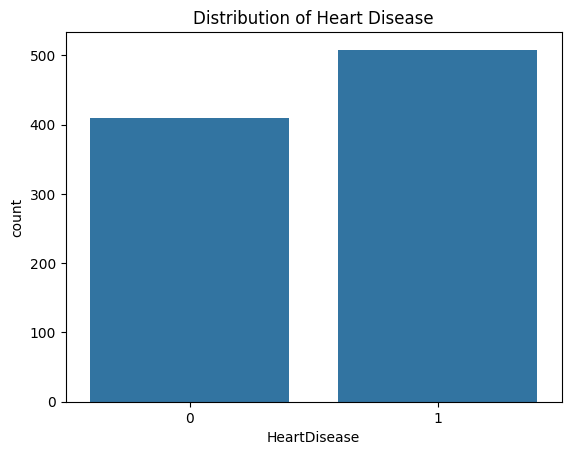

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='HeartDisease', data=df)
plt.title('Distribution of Heart Disease')
plt.show()


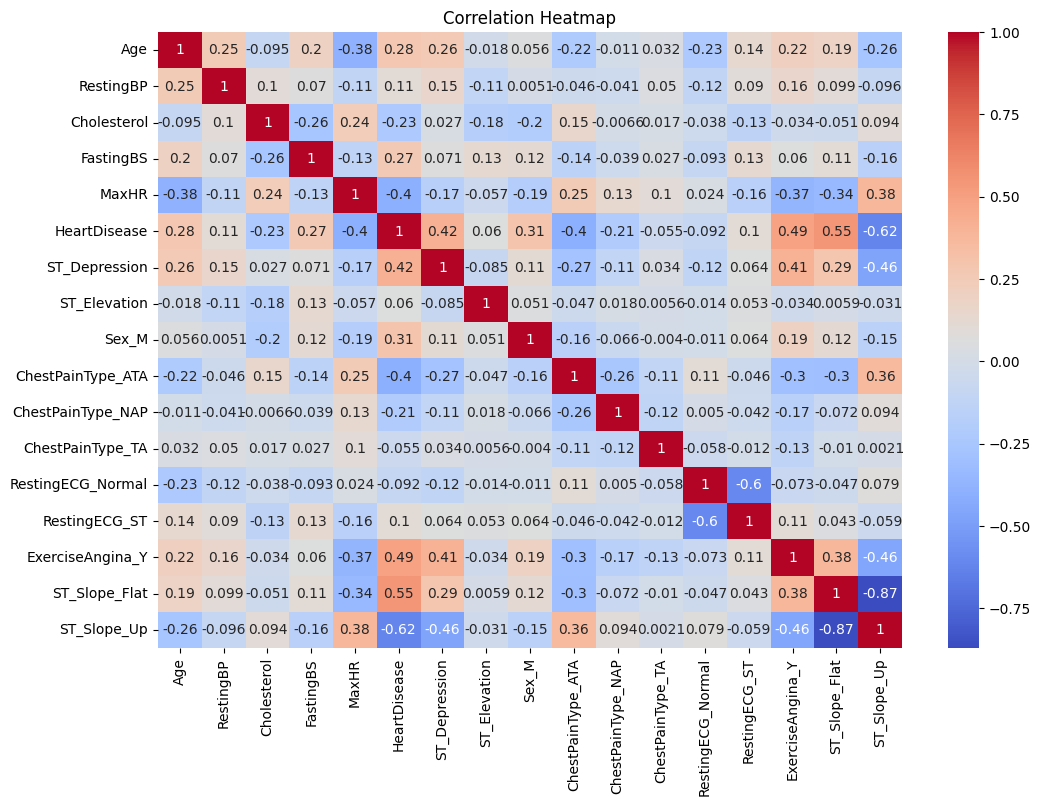

In [50]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


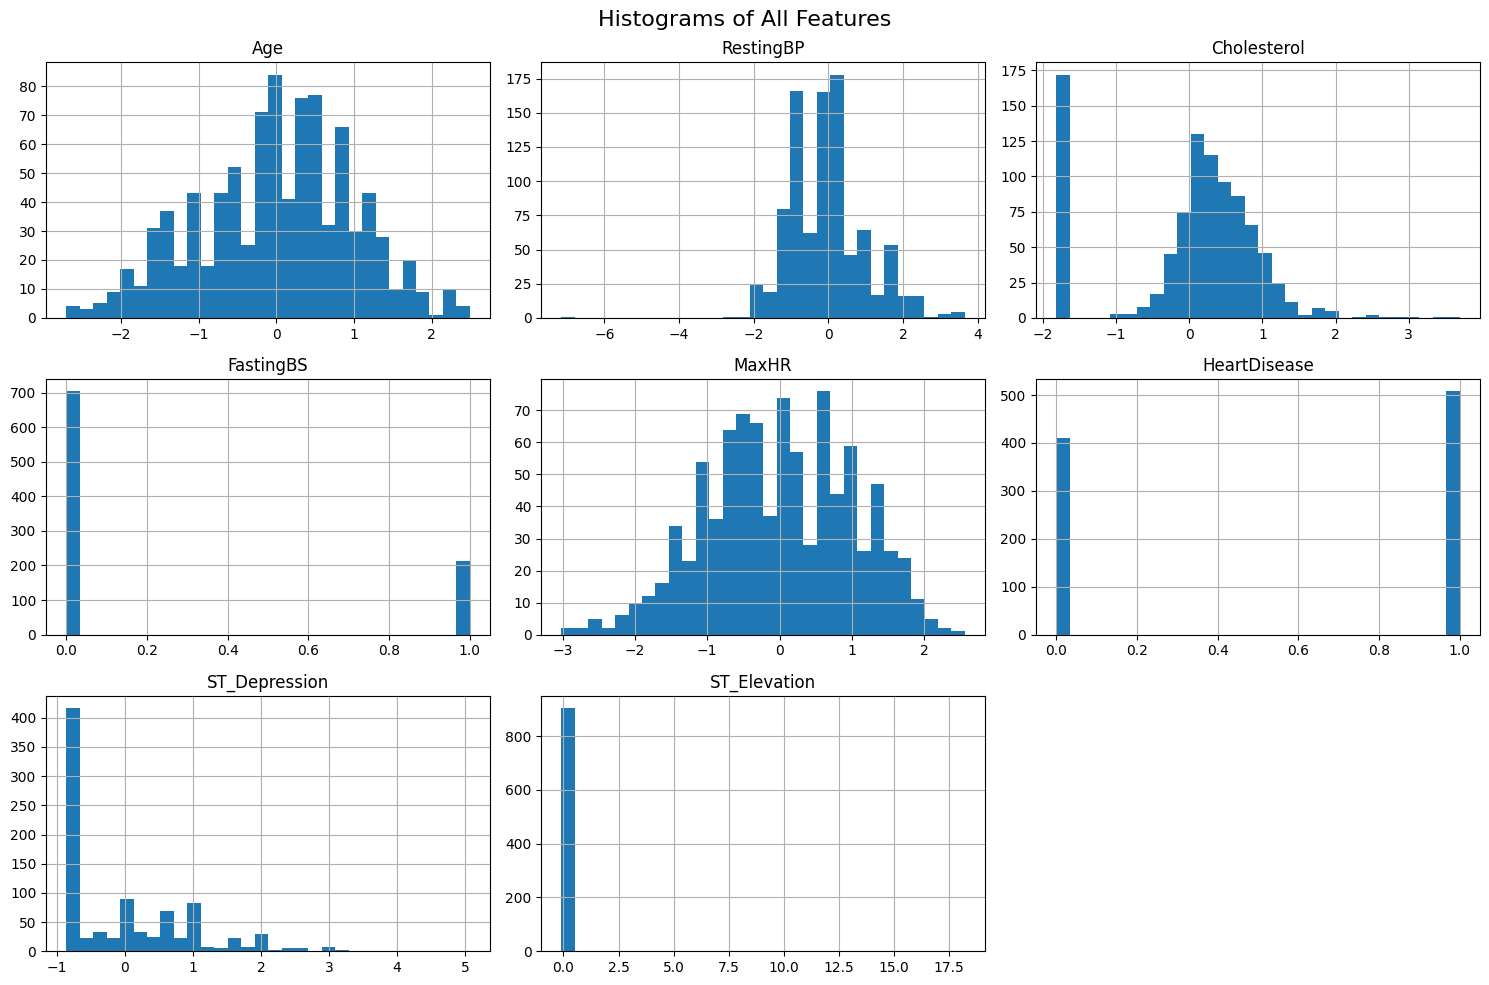

In [51]:
df.hist(figsize=(15, 10), bins=30)
plt.suptitle("Histograms of All Features", fontsize=16)
plt.tight_layout()
plt.show()


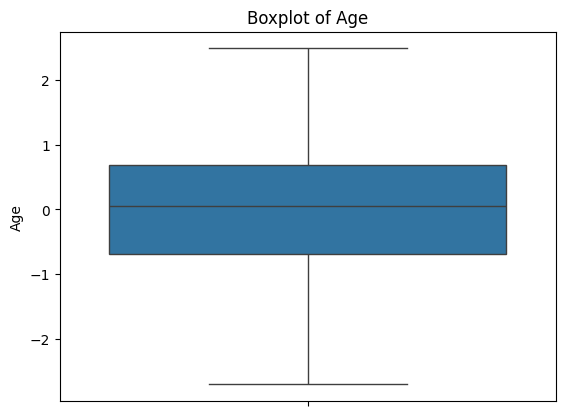

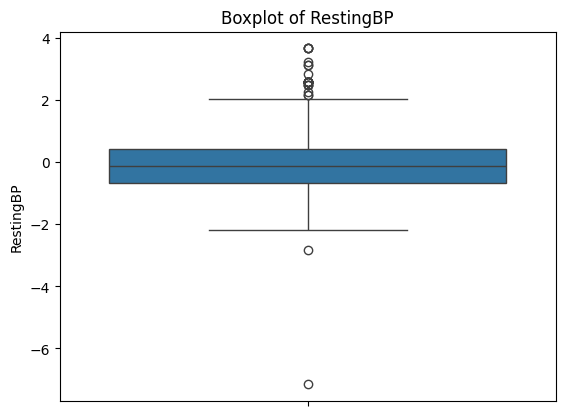

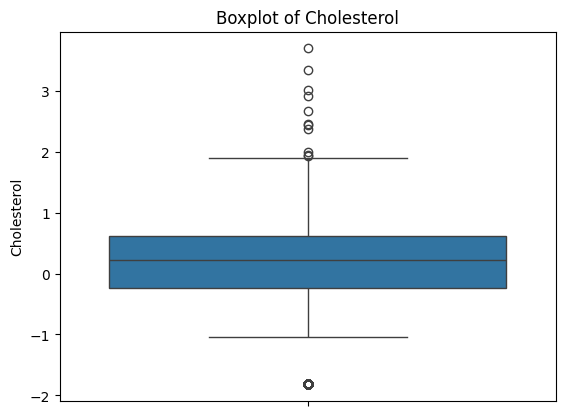

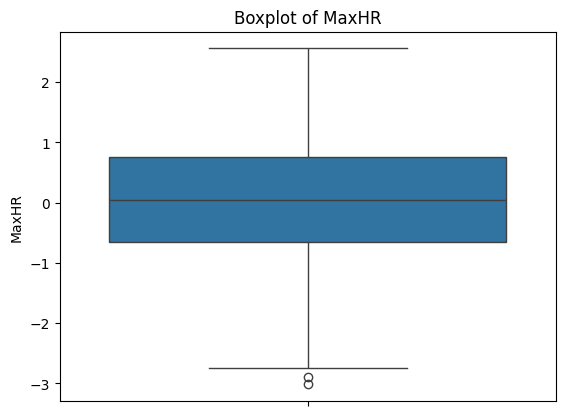

In [52]:
for col in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']:  # Add more numeric columns if you have them
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


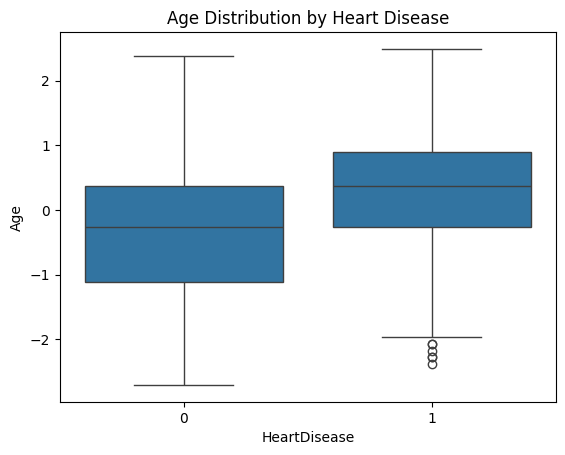

In [53]:
sns.boxplot(x='HeartDisease', y='Age', data=df)
plt.title('Age Distribution by Heart Disease')
plt.show()


In [54]:
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease')
plt.title('Heart Disease by Chest Pain Type')
plt.xticks(rotation=45)
plt.show()



ValueError: Could not interpret value `ChestPainType` for `x`. An entry with this name does not appear in `data`.